# Topic modeling with BERTopic

BERTopic est un modèle de sujet qui exploite les techniques de clustering et une variante de TF-IDF basée sur les classes pour la génération des sujets :
1. création des document embeddings à l'aide d'un modèle de langage pré-entraîné 
2. réduction de la dimensionnalité des embeddings des documents avant de créer des clusters de documents sémantiquement similaires, chacun représentant un sujet distinct
3. application d'une version de TF-IDF basée sur les classes afin d'extraire la représentation des sujets (*topic representation*) de chaque sujet.

*Topic* est un cluster de documents sémantiquement similaires
*Topic representation* est la façon dont les sujets sont décrits ou labélisés, ici par un set de mots extraits des documents du cluster.

=> https://medialab.sciencespo.fr/actu/les-enjeux-de-linformation-a-lere-numerique-vus-par-les-francais/

In [3]:
import polars as pl
from nltk.corpus import stopwords
# from spacy.lang.fr.stop_words import STOP_WORDS
from spacy.lang.en.stop_words import STOP_WORDS
# from spacy.lang.zh.stop_words import STOP_WORDS
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic.vectorizers import ClassTfidfTransformer
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

In [ ]:
# nous avons besoin de `protobuf` version 3.20 pour `SentenceTransformer` avec camembert
# !pip install protobuf==3.20.0

# Préparation des données

Les modèles de sujet avec transformers et word-embedding ne demande, en théorie, aucun prétraitement des données. Cependant, il peut s'avérer utile de normaliser les données, d'enlever les balises HTML (quand ce n'est pas déjà fait), etc. Dans le cas de certains corpus, la suppression de mots spécifiques présents dans tout le corpus peut également s'avérer utile. Après cela, on peut transformer notre dataframe en list de documents.

In [4]:
docs = pl.read_csv("../../data/eng_corpus.csv").with_columns(
    pl.col("text").str.normalize("NFC")
).filter(
    pl.col("text").is_not_null()
).get_column(
    "text"
).to_list() # remplacer captions par la colonne contenant vos publications
docs[0]

'Gpt godI also have a 2nd rubber penis I wear when sexting so nobody can ever blackmail me.“That’s not even me in the video — he has 2 weiners!”Then show your single schlong to prove itWhen I did that the judge said it wasn\'t "relevant" to my speeding ticket."Do you wanna hear about how I was steering?"and"Yes it vibrates, your honour!"As if being slightly under-endowed had nothing to do with the irresistible force that pushed your foot down upon the acceleration pedal. Psssh. The nerve of that judge.what if I actually have 2 schlongs?Wait... doesn\'t everybody?  IS THE SMALLER ONE NOT SUPPOSED TO BE THERE??You only have two?!Yes, please do soReminds me of that DiphallicDude who was debunked... heh.He was debunked?  This confuses me: should I be outraged over something I thought was mildly interesting but not interesting enough to pay any attention to?  I mean, I was perfectly happy thinking that somewhere there was a guy with two dicks, not that it affected me in any way or even seem

In [5]:
len(docs)

275

In [7]:
import spacy
nlp = spacy.load("en_core_web_sm")
lengths = []
for text in docs:
    doc = nlp(text)
    word_count = len([token for token in doc if not token.is_punct and not token.is_space])
    lengths.append(word_count)

avg_length = sum(lengths) / len(lengths) if lengths else 0
avg_length

11270.145454545454

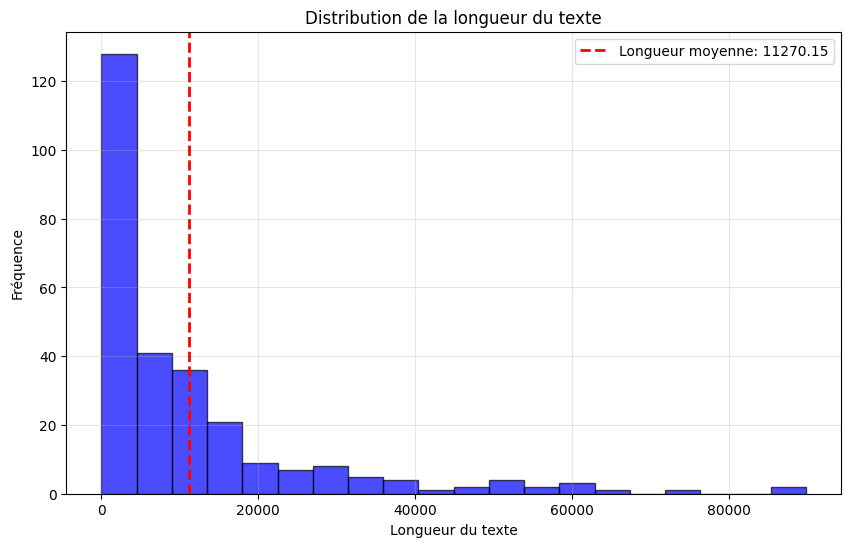

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.hist(lengths, bins=20, alpha=0.7, color='blue', edgecolor='black')

plt.axvline(avg_length, color='red', linestyle='dashed', linewidth=2, label=f'Longueur moyenne: {avg_length:.2f}')

plt.title("Distribution de la longueur du texte")
plt.xlabel("Longueur du texte")
plt.ylabel("Fréquence")
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig('text_length_distribution.png')
plt.show()

Après cela, nous préparons une liste de mots vides, que nous exclurons de la représentation des sujets.

In [4]:
stoplist = list(STOP_WORDS)
# ADDITIONAL_STOPWORDS = []
# stoplist.extend(ADDITIONAL_STOPWORDS)
stoplist[:5]

['everyone', 'give', 'were', 'last', 'somewhere']

# Vectoriser les données

### Word embeddings

La première étape consiste à transformer une chaîne (phrase) en un tableau de nombres (vecteur), autrement dit à vectoriser le texte.
BERTopic peut convertir les documents en embeddings. Cependant, ce processus peut être très coûteux. Il est donc possible de calculer ces embeddings une seule fois et de les transmettre à BERTopic pour éviter de les calculer à chaque fois.

=> https://www.sbert.net/docs/sentence_transformer/pretrained_models.html
=> https://huggingface.co/spaces/mteb/leaderboard 

In [5]:
sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "A journey of a thousand miles begins with a single step."
]

embedding_model = SentenceTransformer("all-MiniLM-L6-v2") # ("dangvantuan/sentence-camembert-base") 
example_embeddings = embedding_model.encode(sentences, show_progress_bar=True)

print(f"Sentence 1 has {len(sentences[0])} characters, and the embedding is {len(example_embeddings[0])} long.")
print(f"Sentence 2 has {len(sentences[1])} characters, and the embedding is {len(example_embeddings[1])} long.")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Sentence 1 has 44 characters, and the embedding is 384 long.
Sentence 2 has 56 characters, and the embedding is 384 long.


Comme le montre la cellule ci-dessus, les embeddings continues créées par le transformateur de phrases `dangvantuan/sentence-camembert-base` ont la même longueur, malgré des phrases de longueurs différentes. Ces embeddings continues ont la même longueur car, plutôt que de représenter directement les mots sous forme de nombres (c'est-à-dire de « sac de mots »), le transformateur crée une représentation riche prenant en compte 768 dimensions.

=> https://github.com/MaartenGr/BERTopic/discussions/822

### UMAP

BERTopic utilise généralement un algorithme de réduction de dimensionnalité (*dimensionality reduction algorithm*) pour réduire la taille des embeddings. Ceci permet d'éviter, dans une certaine mesure, le fléau de la dimension (https://en.wikipedia.org/wiki/Curse_of_dimensionality). 

UMAP est utilisé pour réduire l'espace dimensionnel. Cependant, il affiche par défaut un comportement stochastique qui produit des résultats différents à chaque exécution. Pour éviter cela pendant la période de test, nous pouvons définir un random_state du modèle avant de le transmettre à BERTopic.

```python
UMAP(angular_rp_forest=True, metric='cosine', n_components=10, n_neighbors=30, min_dist=0.1, random_state=42)
```

=> https://umap-learn.readthedocs.io/en/latest/parameters.html

### HDBSCAN

`nr_topics` est le paramètre qui permet de contrôler le nombre de sujets en fusionnant les sujets après leur création. Il permet de créer un nombre fixe de sujets. Il est toutefois conseillé de contrôler le nombre de sujets via le modèle de cluster, HDBSCAN par défaut. HDBSCAN possède un paramètre, `min_cluster_size`, qui contrôle indirectement le nombre de sujets créés. Un `min_cluster_size` élevé génère moins de sujets, tandis qu'un `min_cluster_size` faible en génère davantage.

```python
HDBSCAN(min_cluster_size=13, min_samples=3, prediction_data=True, metric='euclidean', cluster_selection_method='eom')
```

=> https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html

### CountVectorizer

La représentation par défaut des sujets est calculée via c-TF-IDF. Cependant, c-TF-IDF s'appuie sur CountVectorizer, qui convertit le texte en unités. Grâce à CountVectorizer, nous pouvons effectuer plusieurs opérations : supprimer les mots vides, ignorer les mots rares, augmenter la range des n-gram. En d'autres termes, nous pouvons prétraiter les représentations des sujets après l'attribution des documents aux sujets. Cela n'aura aucune incidence sur le processus de clustering.

La tokenisation se fait automatiquement au niveau des espaces, pour le chinois il faut rajouter :

```python
import jieba

def tokenize_zh(text):
    words = jieba.lcut(text)
    return words

vectorizer = CountVectorizer(tokenizer=tokenize_zh)
```

### Construction du modèle

=> https://maartengr.github.io/BERTopic/getting_started/parameter%20tuning/parametertuning.html

In [21]:
def set_model_parameters(embedding_model):

    # Step 1 - extraction des embeddings
    embedding_model = embedding_model

    # Step 2 - réduction des dimensionalité
    umap_model = UMAP(angular_rp_forest=True, metric='cosine', n_components=10, n_neighbors=30, min_dist=0.1)

    # Step 3 - Cluster reduced embeddings
    hdbscan_model = HDBSCAN(min_cluster_size=5, min_samples=5, prediction_data=True, metric='euclidean', cluster_selection_method='eom')
    # hdbscan_model = KMeans(n_clusters=50)
    # hdbscan_model = sklearn.cluster.AgglomerativeClustering(n_clusters=50)

    # Step 4 - Tokenisation des topics

    stoplist = list(STOP_WORDS)
    ADDITIONAL_STOPWORDS = [
        "https", "http", "www", "com", "org", "net", "co", "fr", "de", "uk", "it",
        "the", "a", "an", "and", "or", "is", "are", "was", "were", "be",
        "user_id", "glyph", "removed", "deleted", "meow", "nothingnothing"
    ]
    stoplist.extend(ADDITIONAL_STOPWORDS)

    vectorizer_model = CountVectorizer(stop_words=stoplist, ngram_range=(1, 3), max_df=0.5)

    # Step 5 - Création de la représentation des topics
    ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)

    # Topic model
    return BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        language='english',
        n_gram_range=(1,3),
        nr_topics="auto"
        
    )

# Entrainement du modèle

On encode tous les documents de notre corpus.

In [22]:
# embedding_model = SentenceTransformer("dangvantuan/sentence-camembert-base")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(docs, show_progress_bar=True)

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

On crée une instance du modèle avec tous les paramètres définis et notre modèle d'embeddings.

In [23]:
topic_model = set_model_parameters(embedding_model)

On ajuste le modèle aux documents de notre corpus et aux embeddings que nous avons préparés.

In [24]:
topic_model.fit(docs, embeddings)

-1 est un "faux" cluster contenant toutes les valeurs aberrantes (*outliers*) ; il ne faut donc pas le prendre en compte. Un nom représentatif est attribué à chaque sujet. Le nom par défaut est un identifiant numérique suivi des mots-clés les plus représentatifs.

In [25]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,97,-1_cabin_tomatoes_picnic_chimney,"[cabin, tomatoes, picnic, chimney, bottles, st...","[But does AI understand irony?LolGod, this is ..."
1,0,88,0_r1_server busy_ddos_snowden,"[r1, server busy, ddos, snowden, ccp, deepseek...",[You’re out here doing Gods work lol thank you...
2,1,35,1_developer mode_harold_crowder_equality,"[developer mode, harold, crowder, equality, ra...",[Hot take: AI photos don’t have to be perfect....
3,2,26,2_tmj_hotdog_hot dog_human humor,"[tmj, hotdog, hot dog, human humor, bangs, big...","[I told Nack AI: ""Be a bro""I tried the exact i..."
4,3,22,3_halo_left dead_halo left_bass,"[halo, left dead, halo left, bass, halo left d...",[We kindly ask /u/dtutubalin to respond to thi...
5,4,7,4_modern art_studio ghibli_pollock_taped,"[modern art, studio ghibli, pollock, taped, cr...","[Video calling my Grandma? Yeah, good luck wit..."


In [29]:
topic_model.get_topic(0)

[('r1', 0.20507378036107146),
 ('server busy', 0.16386299075977864),
 ('ddos', 0.154544781850235),
 ('snowden', 0.14167971552882758),
 ('ccp', 0.1412771451800561),
 ('deepseek r1', 0.13273279260828233),
 ('deep seek', 0.13000151085311903),
 ('public data', 0.127850441222992),
 ('tiananmen', 0.12528900592079656),
 ('qwen', 0.12442487128736723)]

In [30]:
topic_model.generate_topic_labels(nr_words=20, topic_prefix=True, word_length=None, separator='  --  ')

['-1  --  cabin  --  tomatoes  --  picnic  --  chimney  --  bottles  --  steaks  --  unemployment  --  pans  --  gutter  --  fire pit',
 '0  --  r1  --  server busy  --  ddos  --  snowden  --  ccp  --  deepseek r1  --  deep seek  --  public data  --  tiananmen  --  qwen',
 '1  --  developer mode  --  harold  --  crowder  --  equality  --  radiologist  --  pod bay  --  firefighter  --  kitten  --  cake lie cake  --  children teachers',
 '2  --  tmj  --  hotdog  --  hot dog  --  human humor  --  bangs  --  big bangs  --  john hamburger  --  tinnitus  --  hotter  --  glurt',
 '3  --  halo  --  left dead  --  halo left  --  bass  --  halo left dead  --  ice cream  --  bong  --  smart robot  --  master chief  --  physical form',
 '4  --  modern art  --  studio ghibli  --  pollock  --  taped  --  craftsmanship  --  understand art  --  wally  --  art people  --  taped wall  --  isn art']

In [31]:
topic_model.save('last_bertopic.model')

2025-05-06 14:16:02,069 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


# Exploration des prédictions du modèles

In [15]:
topic_model = BERTopic.load('last_bertopic.model')

In [32]:
# topics_to_merge = [[3,4,6],[3,15]]
# topic_model.merge_topics(docs, topics_to_merge)

barchart = topic_model.visualize_barchart(top_n_topics=17, title="Représentation des topics", width=400, n_words=7)
barchart.write_html('barchart.html')

In [34]:
topic_labels_dict = {
    0:"Censorship, Surveillance, and Server Disruption",
    1:"AI Personalities, Professions, and Satirical Prompts",
    2:"Quirky Humor, Food, and AI Misinterpretations",
    3:"Gaming References, Sci-Fi Themes, and Pop Culture",
    4:"Art Interpretation, Aesthetics, and Visual Culture"
}

topic_model.set_topic_labels(topic_labels_dict)
barchart = topic_model.visualize_barchart(top_n_topics=17, custom_labels=True, title="Représentation des topics", width=800, n_words=7)
barchart.write_html('barchart.html')

In [35]:
hierarchical_topics = topic_model.hierarchical_topics(docs)
tree = topic_model.get_topic_tree(hierarchical_topics)
tree

100%|██████████| 4/4 [00:00<00:00, 10.76it/s]


'.\n├─■──modern art_studio ghibli_pollock_taped_craftsmanship ── Topic: 4\n└─halo_r1_left dead_tmj_hotdog\n     ├─halo_r1_left dead_server busy_halo left\n     │    ├─■──r1_server busy_ddos_snowden_ccp ── Topic: 0\n     │    └─halo_left dead_halo left_bass_halo left dead\n     │         ├─■──developer mode_harold_crowder_equality_radiologist ── Topic: 1\n     │         └─■──halo_left dead_halo left_bass_halo left dead ── Topic: 3\n     └─■──tmj_hotdog_hot dog_human humor_bangs ── Topic: 2\n'

In [36]:
hierarchical_topics = topic_model.hierarchical_topics(docs)
hierarchy = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics, width=1200) # custom_labels=topic_labels_dict
hierarchy.write_html('hierarchy.html')

100%|██████████| 4/4 [00:00<00:00, 11.39it/s]


In [37]:
heatmap = topic_model.visualize_heatmap(n_clusters=1, width=1200) # custom_labels=topic_labels_dict
heatmap.write_html('heatmap.html')

Visualisation du classement de tous les termes sur tous les sujets. Chaque sujet est représenté par un ensemble de mots. Cependant, ces mots ne représentent pas tous le sujet de manière égale. Cette visualisation montre combien de mots sont nécessaires pour représenter un sujet et à partir de quel seuil l'effet bénéfique de l'ajout de mots commence à diminuer.

Il ya deux axes :
- x : Représente le rang des termes dans chaque sujet. Le terme avec le score c-TF-IDF le plus élevé a un rang de 1, le deuxième terme a un rang de 2, et ainsi de suite.
- y : Montre le score c-TF-IDF des termes. Plus le score est élevé, plus le terme est représentatif du sujet.

In [38]:
topic_model.visualize_term_rank(log_scale=True).write_html("term_rank.html")

In [39]:
topic_model.visualize_topics().write_html("visualize_topics.html")

Enregistrer les résultats dans un csv

In [40]:
PREDICTIONS_FILE = 'bertopic_topics_notebook.csv'

results = topic_model.get_document_info(docs=docs)
# results.to_csv()

# Latent Semantic Analysis (LSA)

LSA commence par créer une matrice terme-document. Les valeurs de la matrice sont généralement des scores TF-IDF qui pondèrent l'importance des mots dans chaque document. La matrice est ensuite décomposée en trois matrices à l'aide de la SVD. Ces matrices capturent les relations entre les termes et les documents. Enfin, en sélectionnant uniquement les premières composantes singulières, LSA réduit la dimensionalité tout en conservant les informations les plus importantes, ce qui permet de découvrir les sujets sous-jacents.

```python
embedding_model = sklearn.pipeline.make_pipeline(
    sklearn.feature_extraction.text.CountVectorizer(analyzer="word", tokenizer=lambda x: x.split(" ")),
    sklearn.decomposition.TruncatedSVD(10)
)
```

=> https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html#sklearn.decomposition.TruncatedSVD

In [41]:
def set_model_parameters_lsa():

    # Step 1 - extraction des embeddings
    embedding_model = sklearn.pipeline.make_pipeline(
        sklearn.feature_extraction.text.CountVectorizer(analyzer="word", tokenizer=lambda x: x.split(" ")),
        sklearn.decomposition.TruncatedSVD(n_components=15)
    )

    # Step 2 - réduction des dimensionalité
    umap_model = UMAP(angular_rp_forest=True, metric='cosine', n_components=10, n_neighbors=20, min_dist=0.1)

    # Step 3 - Cluster reduced embeddings
    hdbscan_model = HDBSCAN(min_cluster_size=10, min_samples=5, prediction_data=True, metric='euclidean', cluster_selection_method='eom')
    # hdbscan_model = KMeans(n_clusters=50)
    # hdbscan_model = sklearn.cluster.AgglomerativeClustering(n_clusters=50)

    # Step 4 - Tokenisation des topics
    stoplist = list(STOP_WORDS)
    ADDITIONAL_STOPWORDS = [
        "https", "http", "www", "com", "org", "net", "co", "fr", "de", "uk", "it",
        "the", "a", "an", "and", "or", "is", "are", "was", "were", "be",
        "user_id", "glyph", "removed", "deleted", "meow", "nothingnothing"
    ]
    stoplist.extend(ADDITIONAL_STOPWORDS)

    vectorizer_model = CountVectorizer(stop_words=stoplist, ngram_range=(1, 2))

    # Step 5 - Création de la représentation des topics
    ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)

    # Topic model
    return BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        language='english',
        n_gram_range=(1,2),
    )

In [42]:
topic_model = set_model_parameters_lsa()

In [43]:
topic_model.fit(docs)

In [44]:
topic_model.generate_topic_labels(nr_words=20, topic_prefix=True, word_length=None, separator='  --  ')

['-1  --  like  --  ai  --  voice  --  don  --  think  --  people  --  know  --  real  --  time  --  model',
 '0  --  chatgpt  --  like  --  gpt  --  ai  --  use  --  asked  --  chat  --  don  --  know  --  language',
 '1  --  deepseek  --  china  --  like  --  table  --  fire  --  pan  --  looks  --  ai  --  look  --  cabin',
 '2  --  teacher  --  student  --  students  --  use  --  ai  --  teachers  --  work  --  o1  --  don  --  deepseek',
 '3  --  ai  --  art  --  people  --  work  --  like  --  think  --  jobs  --  don  --  human  --  world',
 '4  --  32  --  egg  --  waldo  --  cat  --  bro  --  like  --  32 32  --  ai  --  humor  --  step',
 '5  --  jesus  --  nazi  --  salute  --  pope  --  white  --  trump  --  32  --  nazi salute  --  elon  --  people']

In [45]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,86,-1_like_ai_voice_don,"[like, ai, voice, don, think, people, know, re...",[Just using this pinned comment to give credit...
1,0,58,0_chatgpt_like_gpt_ai,"[chatgpt, like, gpt, ai, use, asked, chat, don...","[Looks like the old ""off by one"" problem...I t..."
2,1,48,1_deepseek_china_like_table,"[deepseek, china, like, table, fire, pan, look...",[One thing this whole thing taught me is that ...
3,2,28,2_teacher_student_students_use,"[teacher, student, students, use, ai, teachers...",[## r/ChatGPT is looking for mods — Apply here...
4,3,28,3_ai_art_people_work,"[ai, art, people, work, like, think, jobs, don...","[But does AI understand irony?LolGod, this is ..."
5,4,17,4_32_egg_waldo_cat,"[32, egg, waldo, cat, bro, like, 32 32, ai, hu...","[I told Nack AI: ""Be a bro""I tried the exact i..."
6,5,10,5_jesus_nazi_salute_pope,"[jesus, nazi, salute, pope, white, trump, 32, ...",[Just a reminder that everything Snowden expos...
